# Atelier : Modèles de classification linéaire

**SYS800 - Reconnaissance de formes**

Dans cet atelier, nous allons explorer et comparer quatre modèles de classification :
- **LDA** (Linear Discriminant Analysis) - Génératif
- **QDA** (Quadratic Discriminant Analysis) - Génératif
- **Naive Bayes** - Génératif
- **Régression Logistique** - Discriminatif

Nous utiliserons le jeu de données **Iris** de sklearn, puis explorerons un cas plus complexe avec **Wine**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Configuration des figures
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Reproductibilité
np.random.seed(42)

## 1. Chargement et exploration des données

Le jeu de données **Iris** contient 150 échantillons de fleurs d'iris, répartis en 3 classes (setosa, versicolor, virginica), avec 4 caractéristiques (longueur/largeur des sépales et pétales).

In [2]:
# Chargement des données
iris = load_iris()
X = iris.data
t = iris.target  # Notation Bishop : t pour les cibles
feature_names = iris.feature_names
class_names = iris.target_names

print(f"Dimensions des données : N = {X.shape[0]}, D = {X.shape[1]}")
print(f"\nCaractéristiques : {feature_names}")
print(f"Classes : {class_names}")
print(f"\nDistribution des classes :")
for k, name in enumerate(class_names):
    print(f"  C_{k+1} ({name}) : N_{k+1} = {np.sum(t == k)}")

Dimensions des données : N = 150, D = 4

Caractéristiques : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes : ['setosa' 'versicolor' 'virginica']

Distribution des classes :
  C_1 (setosa) : N_1 = 50
  C_2 (versicolor) : N_2 = 50
  C_3 (virginica) : N_3 = 50


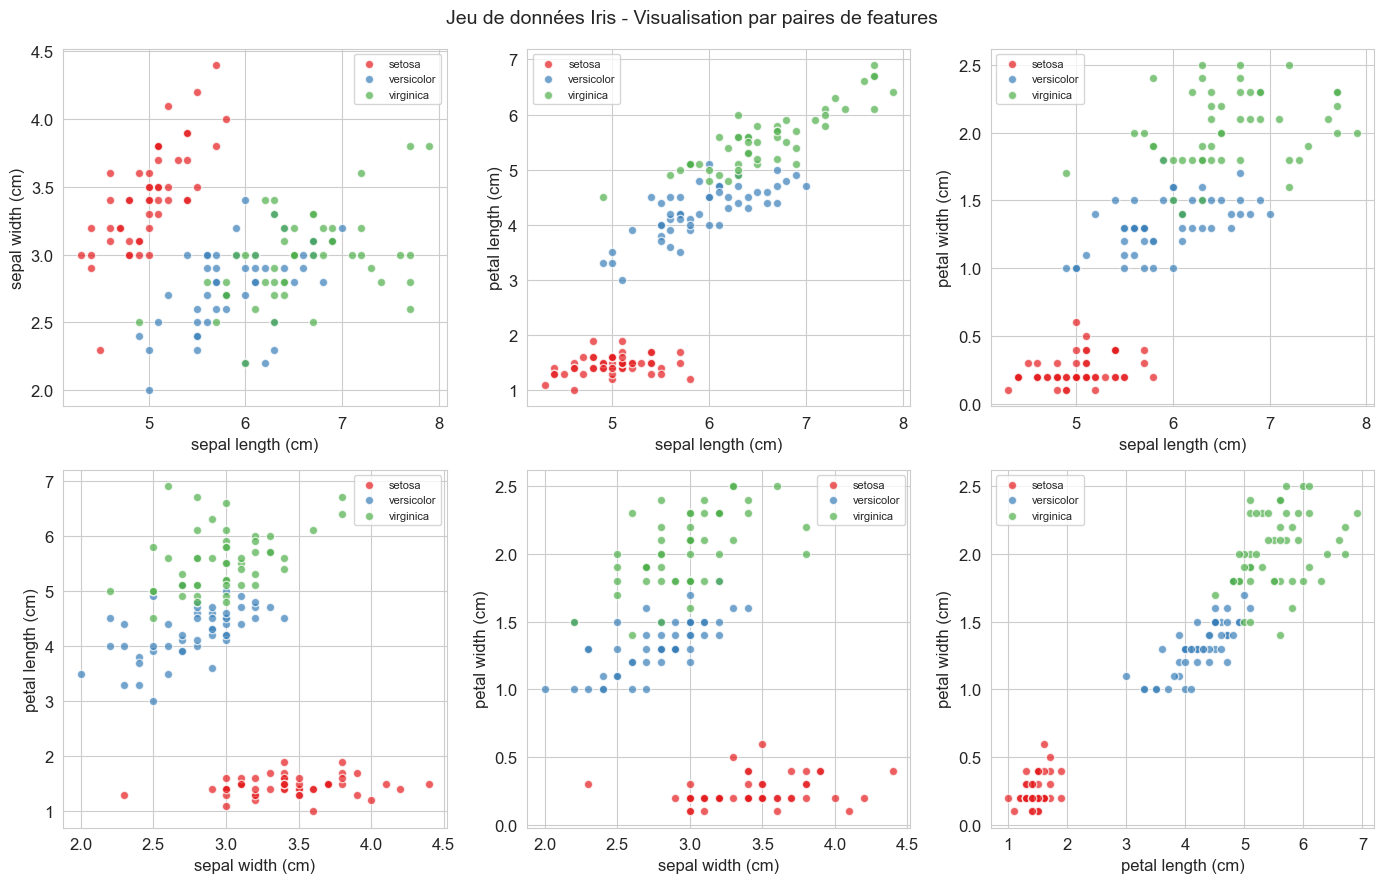

In [3]:
# Visualisation par paires de features
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

colors = ['#e41a1c', '#377eb8', '#4daf4a']
pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

for ax, (i, j) in zip(axes, pairs):
    for k in range(3):
        mask = t == k
        ax.scatter(X[mask, i], X[mask, j], c=colors[k], 
                   label=class_names[k], alpha=0.7, edgecolors='w')
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel(feature_names[j])
    ax.legend(loc='best', fontsize=8)

plt.suptitle('Jeu de données Iris - Visualisation par paires de features', fontsize=14)
plt.tight_layout()
plt.show()

### Question 1
Observez les graphiques. Quelles paires de features semblent les plus discriminantes ? Les classes sont-elles linéairement séparables ?

## 2. Préparation des données

Pour visualiser les frontières de décision, nous allons d'abord travailler avec **2 features** seulement (petal length et petal width).

In [4]:
# Sélection de 2 features pour la visualisation
# Features 2 et 3 : petal length et petal width (les plus discriminantes)
X_2d = X[:, 2:4]

# Séparation train/test
X_train, X_test, t_train, t_test = train_test_split(
    X_2d, t, test_size=0.3, random_state=42, stratify=t
)

print(f"Ensemble d'entraînement : {X_train.shape[0]} échantillons")
print(f"Ensemble de test : {X_test.shape[0]} échantillons")

Ensemble d'entraînement : 105 échantillons
Ensemble de test : 45 échantillons


## 3. Fonction de visualisation des frontières de décision

Cette fonction trace les régions de décision d'un classifieur.

In [5]:
def plot_decision_boundary(clf, X, t, title, ax=None, h=0.02):
    """
    Trace les frontières de décision d'un classifieur.
    
    Paramètres:
    -----------
    clf : classifieur entraîné
    X : données (N x 2)
    t : étiquettes
    title : titre du graphique
    ax : axes matplotlib (optionnel)
    h : pas de la grille
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # Création de la grille
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Prédiction sur la grille
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Couleurs
    cmap_light = ListedColormap(['#ffcccc', '#ccccff', '#ccffcc'])
    cmap_bold = ListedColormap(['#e41a1c', '#377eb8', '#4daf4a'])
    
    # Régions de décision
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5)
    
    # Points de données
    scatter = ax.scatter(X[:, 0], X[:, 1], c=t, cmap=cmap_bold, 
                         edgecolors='k', s=50, alpha=0.8)
    
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('Petal length (cm)')
    ax.set_ylabel('Petal width (cm)')
    ax.set_title(title)
    
    return ax

## 4. Analyse Discriminante Linéaire (LDA)

### Rappel théorique

LDA suppose que chaque classe suit une distribution gaussienne avec une **covariance partagée** :

$$p(\mathbf{x} | C_k) = \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma})$$

La fonction discriminante est **linéaire** :
$$y_k(\mathbf{x}) = \mathbf{w}_k^\top \mathbf{x} + w_{k0}$$

avec $\mathbf{w}_k = \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_k$

In [9]:
# Entraînement de LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, t_train)

# Prédiction et évaluation
t_pred_lda = lda.predict(X_test)
acc_lda = accuracy_score(t_test, t_pred_lda)

print(f"Accuracy LDA : {acc_lda:.2%}")
print(f"\nMoyennes estimées (μ_k) :")
for k, name in enumerate(class_names):
    print(f"  {name}: {lda.means_[k]}")

Accuracy LDA : 91.11%

Moyennes estimées (μ_k) :
  setosa: [1.48571429 0.24      ]
  versicolor: [4.23714286 1.30857143]
  virginica: [5.63142857 2.06857143]


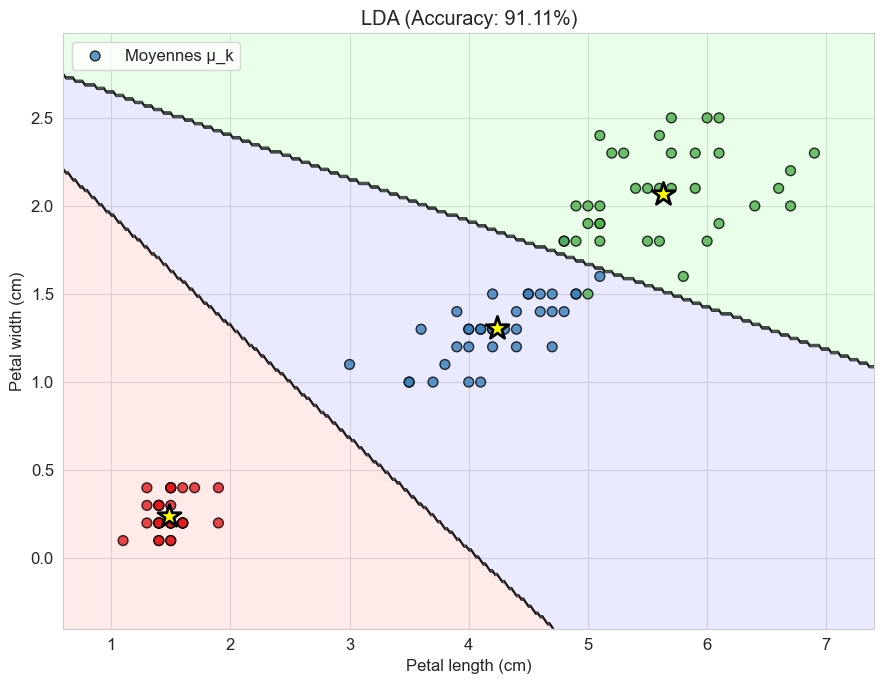

In [13]:
# Visualisation des frontières LDA
fig, ax = plt.subplots(figsize=(9, 7))
plot_decision_boundary(lda, X_train, t_train, f'LDA (Accuracy: {acc_lda:.2%})', ax)

# Ajout des moyennes
for k in range(3):
    ax.scatter(lda.means_[k, 0], lda.means_[k, 1], 
               marker='*', s=300, c='yellow', edgecolors='k', linewidths=2,
               label=f'μ_{k+1}' if k == 0 else '')

ax.legend(['Moyennes μ_k'], loc='upper left')
plt.tight_layout()
plt.show()

## 5. Analyse Discriminante Quadratique (QDA)

### Rappel théorique

QDA relaxe l'hypothèse de covariance partagée. Chaque classe a sa **propre matrice de covariance** :

$$p(\mathbf{x} | C_k) = \mathcal{N}(\mathbf{x} | \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

La fonction discriminante devient **quadratique** en $\mathbf{x}$, ce qui donne des frontières courbes.

In [10]:
# Entraînement de QDA
qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(X_train, t_train)

# Prédiction et évaluation
t_pred_qda = qda.predict(X_test)
acc_qda = accuracy_score(t_test, t_pred_qda)

print(f"Accuracy QDA : {acc_qda:.4f}")
print(f"\nMatrices de covariance (diagonales de Σ_k) :")
for k, name in enumerate(class_names):
    print(f"  {name}: diag = {np.diag(qda.covariance_[k])}")

Accuracy QDA : 0.9333

Matrices de covariance (diagonales de Σ_k) :
  setosa: diag = [0.02361345 0.00952941]
  versicolor: diag = [0.21769748 0.03668908]
  virginica: diag = [0.33221849 0.0657479 ]


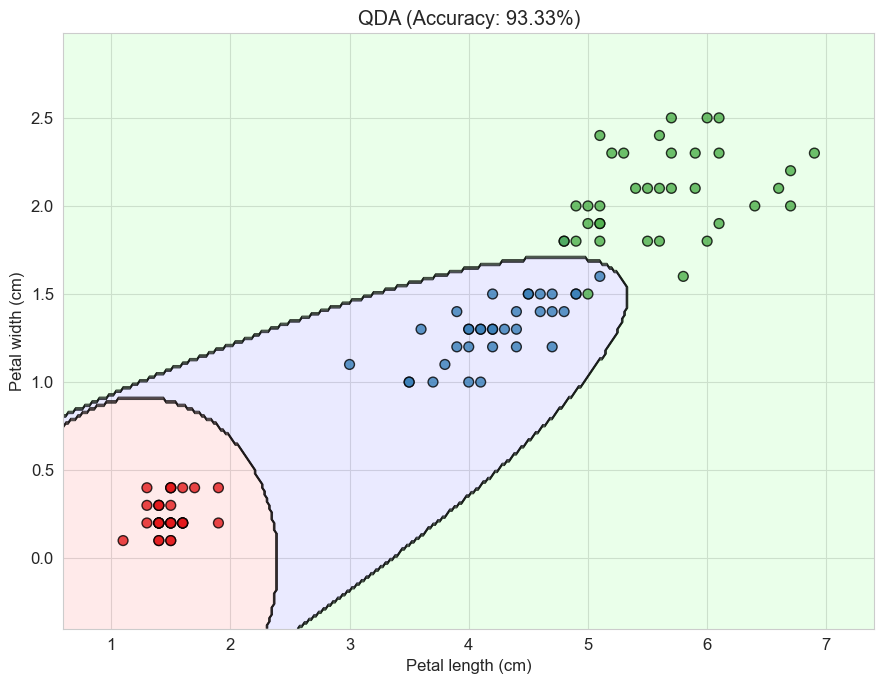

In [11]:
# Visualisation des frontières QDA
fig, ax = plt.subplots(figsize=(9, 7))
plot_decision_boundary(qda, X_train, t_train, f'QDA (Accuracy: {acc_qda:.2%})', ax)
plt.tight_layout()
plt.show()

### Visualisation des ellipses de covariance

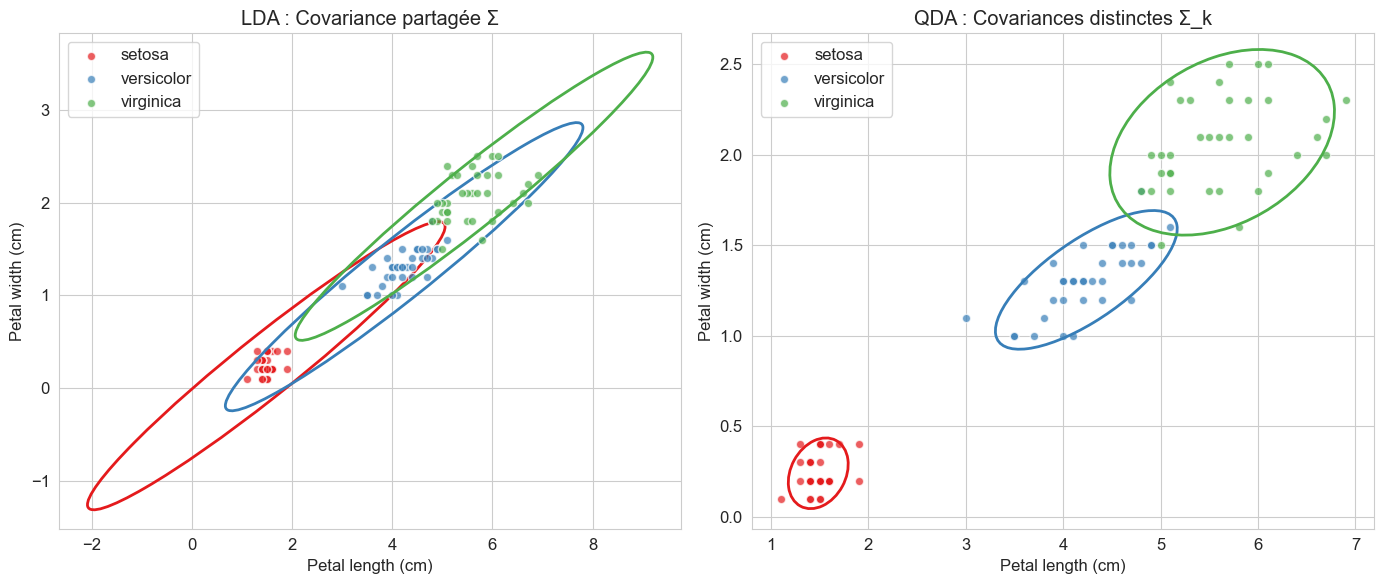

In [14]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

def plot_covariance_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """Trace une ellipse de confiance pour une gaussienne 2D."""
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

# Comparaison LDA vs QDA avec ellipses
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#e41a1c', '#377eb8', '#4daf4a']

# LDA : covariance partagée
ax = axes[0]
for k in range(3):
    mask = t_train == k
    ax.scatter(X_train[mask, 0], X_train[mask, 1], c=colors[k], 
               label=class_names[k], alpha=0.7, edgecolors='w')
    # Même covariance pour toutes les classes (pooled)
    cov_pooled = np.cov(X_train.T)
    plot_covariance_ellipse(lda.means_[k], cov_pooled, ax, 
                            facecolor='none', edgecolor=colors[k], linewidth=2)
ax.set_title('LDA : Covariance partagée Σ')
ax.set_xlabel('Petal length (cm)')
ax.set_ylabel('Petal width (cm)')
ax.legend()

# QDA : covariances distinctes
ax = axes[1]
for k in range(3):
    mask = t_train == k
    ax.scatter(X_train[mask, 0], X_train[mask, 1], c=colors[k], 
               label=class_names[k], alpha=0.7, edgecolors='w')
    plot_covariance_ellipse(qda.means_[k], qda.covariance_[k], ax,
                            facecolor='none', edgecolor=colors[k], linewidth=2)
ax.set_title('QDA : Covariances distinctes Σ_k')
ax.set_xlabel('Petal length (cm)')
ax.set_ylabel('Petal width (cm)')
ax.legend()

plt.tight_layout()
plt.show()

## 6. Classifieur Bayésien Naïf (Naive Bayes)

### Rappel théorique

Naive Bayes suppose l'**indépendance conditionnelle** des features :

$$p(\mathbf{x} | C_k) = \prod_{d=1}^{D} p(x_d | C_k)$$

Pour le **Gaussian Naive Bayes** :
$$p(x_d | C_k) = \mathcal{N}(x_d | \mu_{kd}, \sigma_{kd}^2)$$

C'est équivalent à QDA avec des matrices de covariance **diagonales**.

In [15]:
# Entraînement de Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, t_train)

# Prédiction et évaluation
t_pred_gnb = gnb.predict(X_test)
acc_gnb = accuracy_score(t_test, t_pred_gnb)

print(f"Accuracy Naive Bayes : {acc_gnb:.4f}")
print(f"\nMoyennes par classe et feature (μ_kd) :")
print(gnb.theta_)
print(f"\nVariances par classe et feature (σ²_kd) :")
print(gnb.var_)

Accuracy Naive Bayes : 0.9333

Moyennes par classe et feature (μ_kd) :
[[1.48571429 0.24      ]
 [4.23714286 1.30857143]
 [5.63142857 2.06857143]]

Variances par classe et feature (σ²_kd) :
[[0.02293878 0.00925715]
 [0.21147755 0.03564082]
 [0.32272653 0.06386939]]


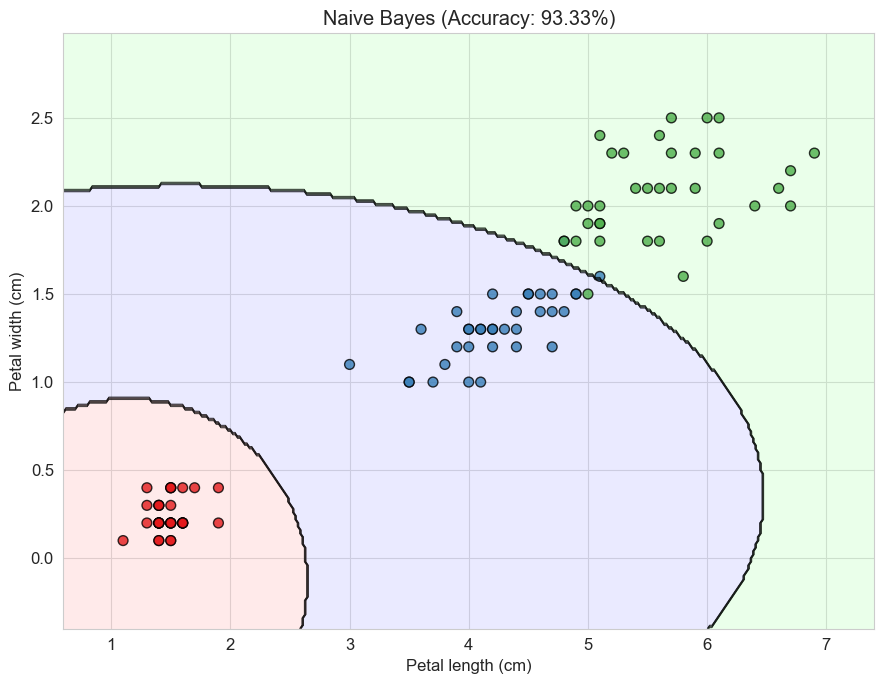

In [16]:
# Visualisation des frontières Naive Bayes
fig, ax = plt.subplots(figsize=(9, 7))
plot_decision_boundary(gnb, X_train, t_train, f'Naive Bayes (Accuracy: {acc_gnb:.2%})', ax)
plt.tight_layout()
plt.show()

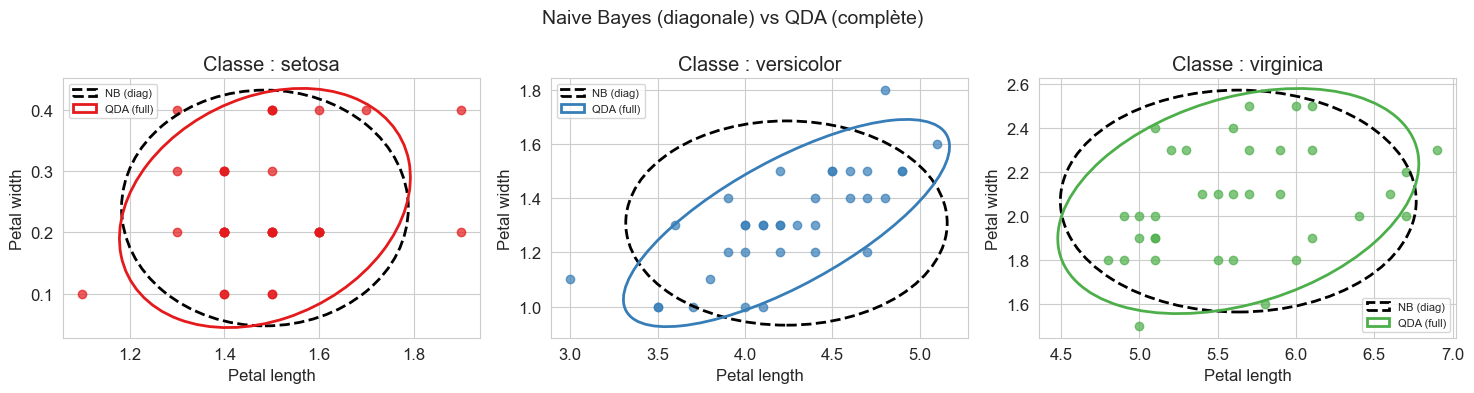

In [17]:
# Visualisation de l'hypothèse d'indépendance (covariances diagonales)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for k in range(3):
    ax = axes[k]
    mask = t_train == k
    ax.scatter(X_train[mask, 0], X_train[mask, 1], c=colors[k], alpha=0.7)
    
    # Ellipse diagonale (Naive Bayes)
    cov_diag = np.diag(gnb.var_[k])
    plot_covariance_ellipse(gnb.theta_[k], cov_diag, ax,
                            facecolor='none', edgecolor='black', 
                            linewidth=2, linestyle='--', label='NB (diag)')
    
    # Ellipse complète (QDA)
    plot_covariance_ellipse(qda.means_[k], qda.covariance_[k], ax,
                            facecolor='none', edgecolor=colors[k], 
                            linewidth=2, label='QDA (full)')
    
    ax.set_title(f'Classe : {class_names[k]}')
    ax.set_xlabel('Petal length')
    ax.set_ylabel('Petal width')
    ax.legend(fontsize=8)

plt.suptitle('Naive Bayes (diagonale) vs QDA (complète)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Régression Logistique

### Rappel théorique

La régression logistique est un modèle **discriminatif** qui modélise directement les posteriors :

$$p(C_k | \mathbf{x}) = \frac{\exp(\mathbf{w}_k^\top \mathbf{x})}{\sum_j \exp(\mathbf{w}_j^\top \mathbf{x})}$$

Les paramètres sont estimés par **maximum de vraisemblance** (entropie croisée).

In [18]:
# Entraînement de la régression logistique
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, t_train)

# Prédiction et évaluation
t_pred_logreg = logreg.predict(X_test)
acc_logreg = accuracy_score(t_test, t_pred_logreg)

print(f"Accuracy Régression Logistique : {acc_logreg:.4f}")
print(f"\nCoefficients (w_k) :")
print(logreg.coef_)
print(f"\nBiais (w_k0) :")
print(logreg.intercept_)

Accuracy Régression Logistique : 0.9333

Coefficients (w_k) :
[[-2.4868809  -1.07583988]
 [ 0.12787684 -0.80978604]
 [ 2.35900406  1.88562592]]

Biais (w_k0) :
[ 10.07532388   2.70002668 -12.77535057]


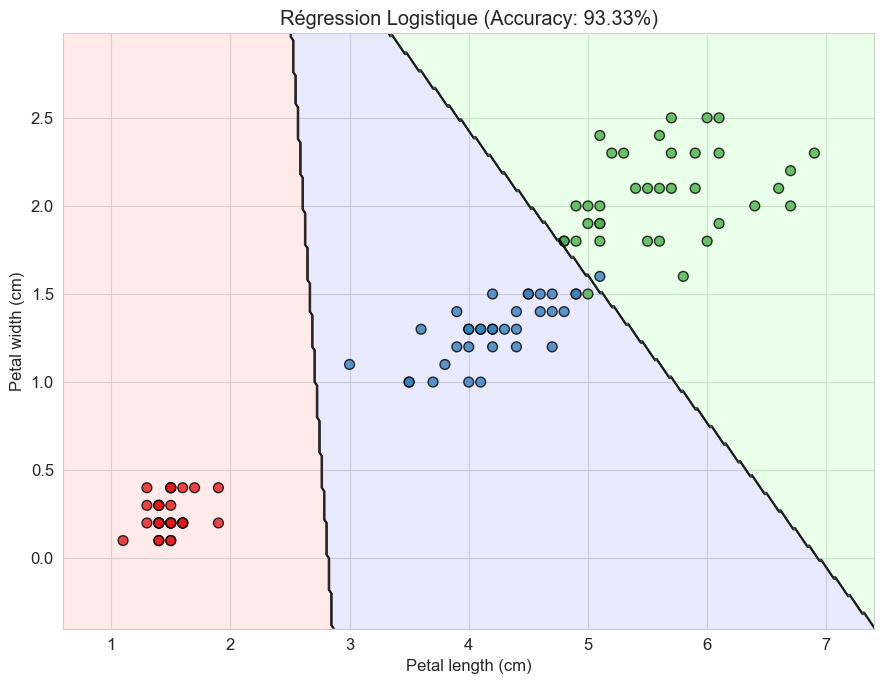

In [19]:
# Visualisation des frontières Régression Logistique
fig, ax = plt.subplots(figsize=(9, 7))
plot_decision_boundary(logreg, X_train, t_train, 
                       f'Régression Logistique (Accuracy: {acc_logreg:.2%})', ax)
plt.tight_layout()
plt.show()

In [20]:
# Probabilités prédites
proba_logreg = logreg.predict_proba(X_test)

# Affichage pour quelques exemples
print("Probabilités p(C_k | x) pour les 5 premiers exemples de test :")
print(f"{'Vraie classe':<15} {'P(setosa)':<12} {'P(versicolor)':<15} {'P(virginica)':<12}")
print("-" * 55)
for i in range(5):
    print(f"{class_names[t_test[i]]:<15} {proba_logreg[i, 0]:<12.4f} {proba_logreg[i, 1]:<15.4f} {proba_logreg[i, 2]:<12.4f}")

Probabilités p(C_k | x) pour les 5 premiers exemples de test :
Vraie classe    P(setosa)    P(versicolor)   P(virginica)
-------------------------------------------------------
virginica       0.0000       0.0313          0.9687      
versicolor      0.0039       0.7683          0.2278      
virginica       0.0009       0.5129          0.4862      
versicolor      0.0032       0.6608          0.3360      
virginica       0.0011       0.4229          0.5760      


## 8. Comparaison des modèles

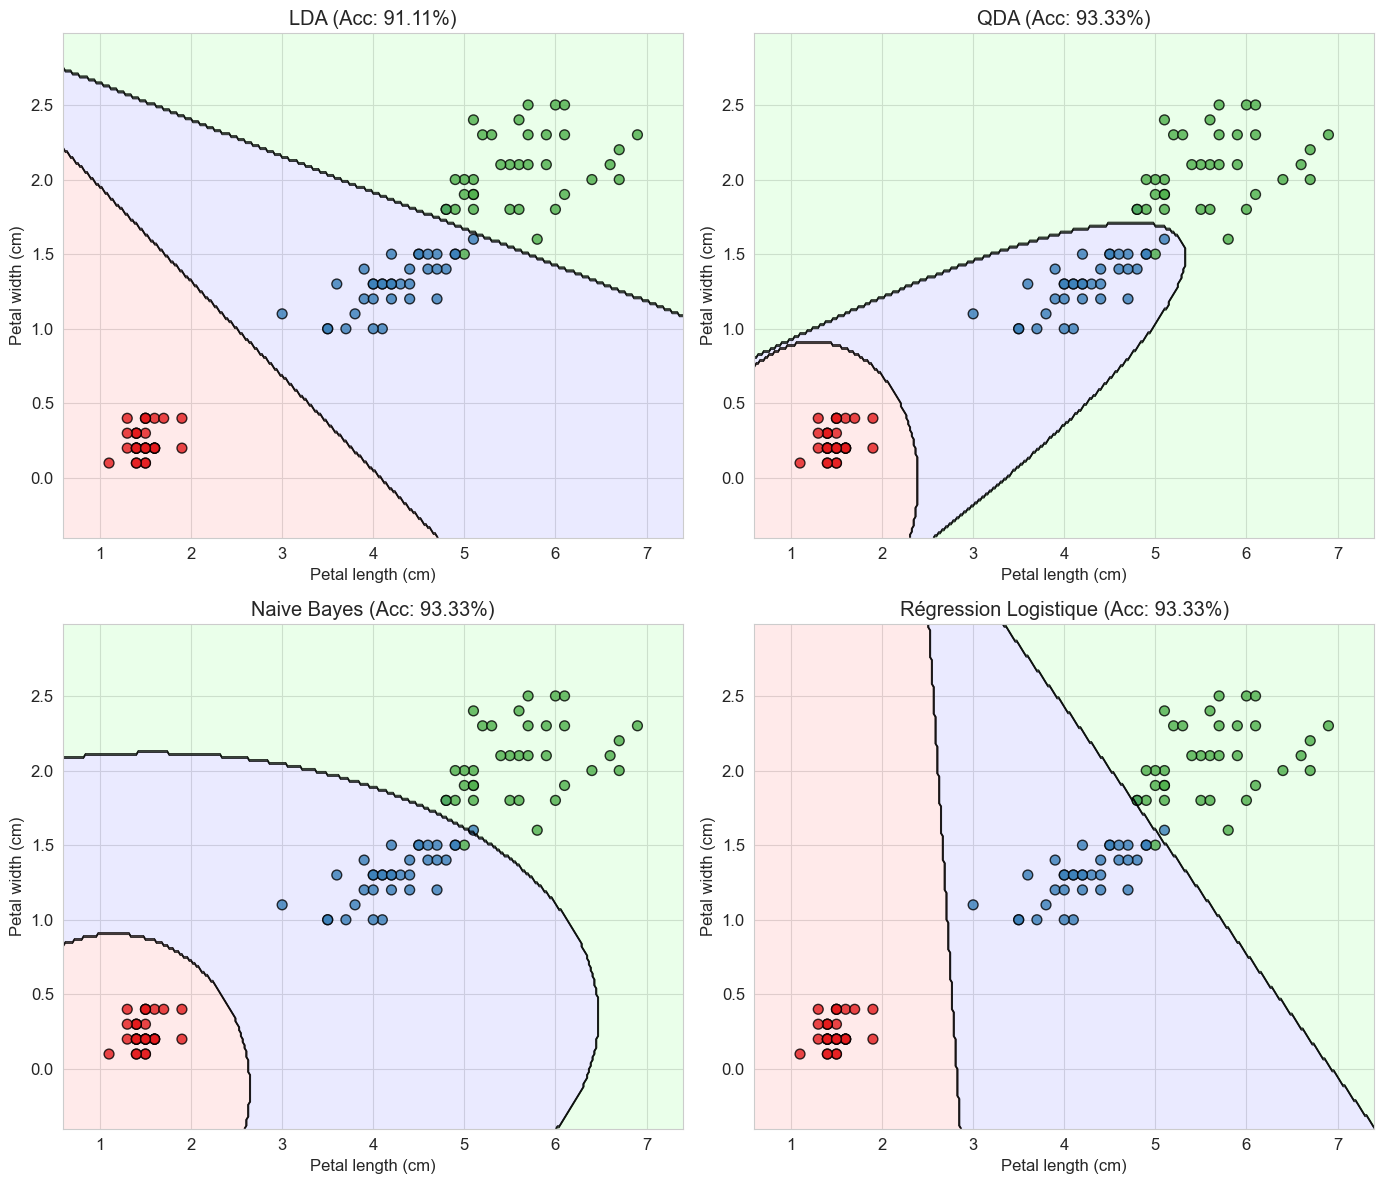

In [21]:
# Comparaison visuelle des frontières
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

models = [
    (lda, 'LDA', acc_lda),
    (qda, 'QDA', acc_qda),
    (gnb, 'Naive Bayes', acc_gnb),
    (logreg, 'Régression Logistique', acc_logreg)
]

for ax, (model, name, acc) in zip(axes.flatten(), models):
    plot_decision_boundary(model, X_train, t_train, 
                           f'{name} (Acc: {acc:.2%})', ax)

plt.tight_layout()
plt.show()

In [22]:
# Tableau récapitulatif
print("=" * 60)
print(f"{'Modèle':<25} {'Type':<15} {'Accuracy':<10}")
print("=" * 60)
print(f"{'LDA':<25} {'Génératif':<15} {acc_lda:.4f}")
print(f"{'QDA':<25} {'Génératif':<15} {acc_qda:.4f}")
print(f"{'Naive Bayes':<25} {'Génératif':<15} {acc_gnb:.4f}")
print(f"{'Régression Logistique':<25} {'Discriminatif':<15} {acc_logreg:.4f}")
print("=" * 60)

Modèle                    Type            Accuracy  
LDA                       Génératif       0.9111
QDA                       Génératif       0.9333
Naive Bayes               Génératif       0.9333
Régression Logistique     Discriminatif   0.9333


In [ ]:
# Validation croisée pour une évaluation plus robuste
models_dict = {
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'Naive Bayes': GaussianNB(),
    'Rég. Logistique': LogisticRegression(max_iter=1000)
}

print("Validation croisée (5-fold) sur toutes les features :")
print("=" * 50)

cv_results = {}
for name, model in models_dict.items():
    scores = cross_val_score(model, X, t, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:<20} : {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

Validation croisée (5-fold) sur toutes les features :
LDA                  : 0.9800 (+/- 0.0533)
QDA                  : 0.9800 (+/- 0.0533)
Naive Bayes          : 0.9533 (+/- 0.0533)
Rég. Logistique      : 0.9733 (+/- 0.0499)


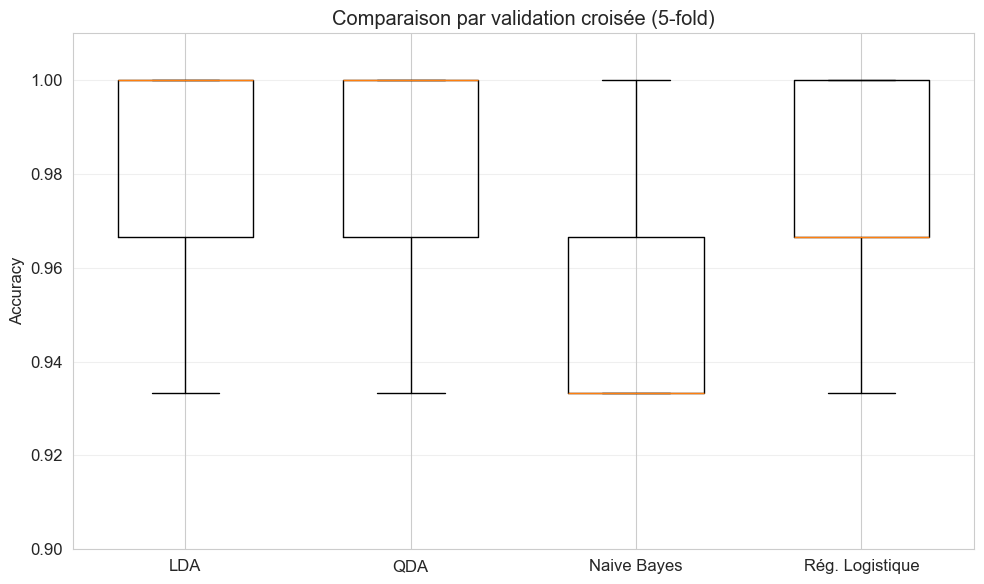

In [24]:
# Visualisation des résultats de validation croisée
fig, ax = plt.subplots(figsize=(10, 6))

positions = range(len(cv_results))
bp = ax.boxplot(cv_results.values(), positions=positions, widths=0.6)
ax.set_xticklabels(cv_results.keys())
ax.set_ylabel('Accuracy')
ax.set_title('Comparaison par validation croisée (5-fold)')
ax.set_ylim([0.9, 1.01])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Matrices de confusion

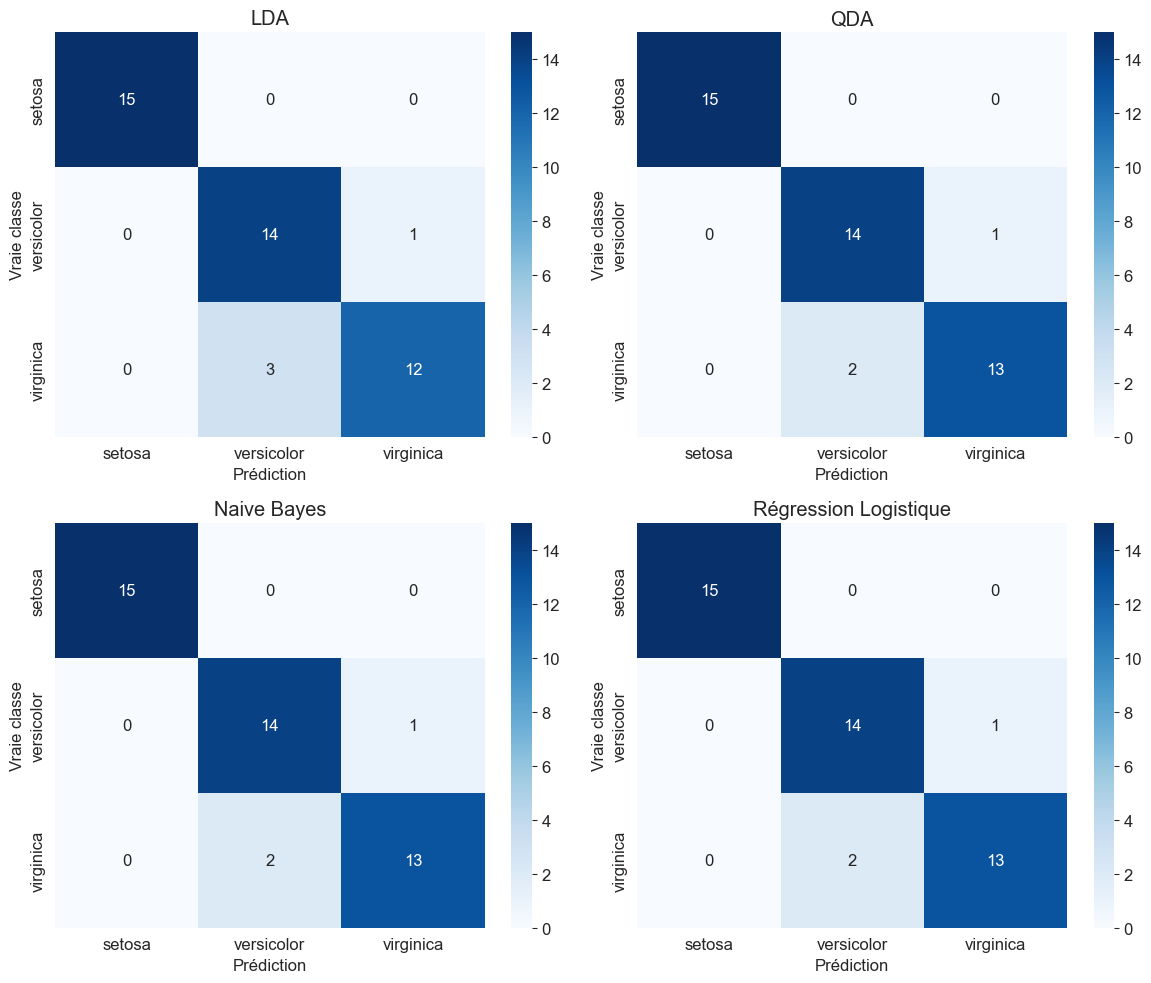

In [25]:
# Matrices de confusion pour tous les modèles
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

predictions = [
    (t_pred_lda, 'LDA'),
    (t_pred_qda, 'QDA'),
    (t_pred_gnb, 'Naive Bayes'),
    (t_pred_logreg, 'Régression Logistique')
]

for ax, (pred, name) in zip(axes.flatten(), predictions):
    cm = confusion_matrix(t_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{name}')
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Vraie classe')

plt.tight_layout()
plt.show()

## 10. Étude de cas : Dataset Wine

Testons les modèles sur un jeu de données plus complexe avec plus de features.

In [26]:
# Chargement du dataset Wine
wine = load_wine()
X_wine = wine.data
t_wine = wine.target

print(f"Dataset Wine : N = {X_wine.shape[0]}, D = {X_wine.shape[1]}")
print(f"Classes : {wine.target_names}")

# Standardisation (important pour la régression logistique)
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

# Validation croisée
print("\nValidation croisée (5-fold) sur Wine :")
print("=" * 50)

for name, model in models_dict.items():
    if name == 'Rég. Logistique':
        scores = cross_val_score(model, X_wine_scaled, t_wine, cv=5)
    else:
        scores = cross_val_score(model, X_wine, t_wine, cv=5)
    print(f"{name:<20} : {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

Dataset Wine : N = 178, D = 13
Classes : ['class_0' 'class_1' 'class_2']

Validation croisée (5-fold) sur Wine :
LDA                  : 0.9717 (+/- 0.0504)
QDA                  : 0.9551 (+/- 0.0274)
Naive Bayes          : 0.9663 (+/- 0.0423)
Rég. Logistique      : 0.9889 (+/- 0.0272)


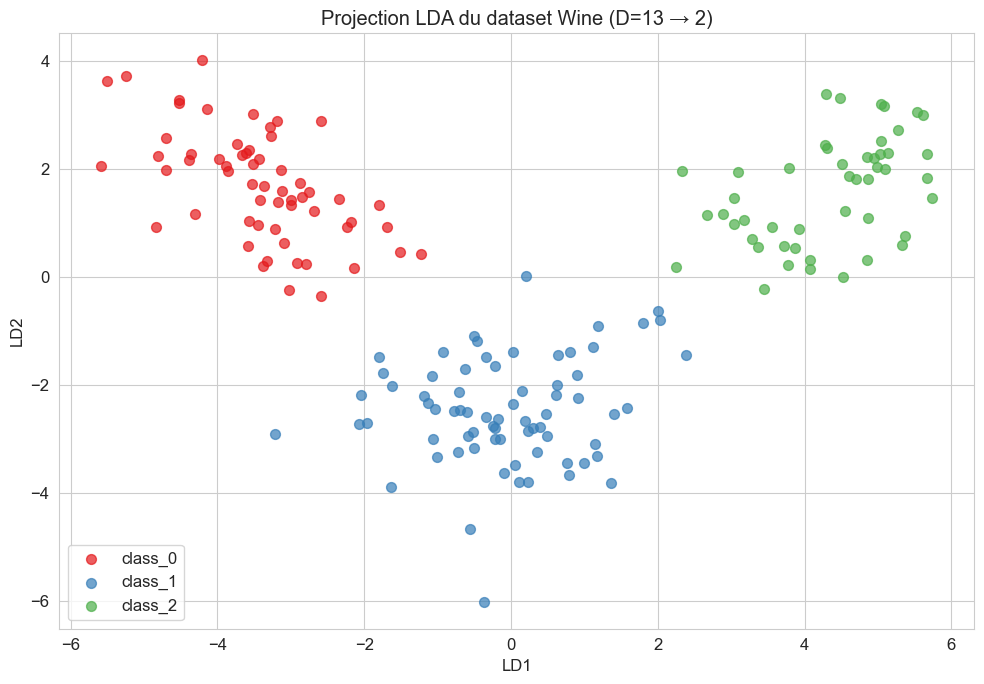

Variance expliquée par les composantes LDA : [0.68747889 0.31252111]


In [27]:
# Projection LDA pour visualisation
lda_wine = LinearDiscriminantAnalysis(n_components=2)
X_wine_lda = lda_wine.fit_transform(X_wine, t_wine)

fig, ax = plt.subplots(figsize=(10, 7))
for k in range(3):
    mask = t_wine == k
    ax.scatter(X_wine_lda[mask, 0], X_wine_lda[mask, 1], 
               c=colors[k], label=wine.target_names[k], alpha=0.7, s=50)

ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_title('Projection LDA du dataset Wine (D=13 → 2)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Variance expliquée par les composantes LDA : {lda_wine.explained_variance_ratio_}")

## 11. Exercices

### Exercice 1 : Nombre de paramètres
Pour le dataset Iris (D=4, K=3), calculez le nombre de paramètres de chaque modèle :
- LDA : $K \cdot D$ (moyennes) + $D(D+1)/2$ (covariance) + $K-1$ (priors)
- QDA : $K \cdot D$ (moyennes) + $K \cdot D(D+1)/2$ (covariances) + $K-1$ (priors)
- Naive Bayes : $K \cdot D$ (moyennes) + $K \cdot D$ (variances) + $K-1$ (priors)
- Régression Logistique : $(K-1) \cdot (D+1)$ (poids + biais)

In [28]:
# Exercice 1 : Complétez le calcul
D = 4  # Nombre de features
K = 3  # Nombre de classes

n_params_lda = K * D + D * (D + 1) // 2 + (K - 1)
n_params_qda = K * D + K * D * (D + 1) // 2 + (K - 1)
n_params_nb = K * D + K * D + (K - 1)
n_params_logreg = (K - 1) * (D + 1)

print(f"Nombre de paramètres :")
print(f"  LDA : {n_params_lda}")
print(f"  QDA : {n_params_qda}")
print(f"  Naive Bayes : {n_params_nb}")
print(f"  Rég. Logistique : {n_params_logreg}")

Nombre de paramètres :
  LDA : 24
  QDA : 44
  Naive Bayes : 26
  Rég. Logistique : 10


### Exercice 2 : Effet de la taille d'échantillon

Étudiez l'impact de la taille de l'ensemble d'entraînement sur les performances de chaque modèle.

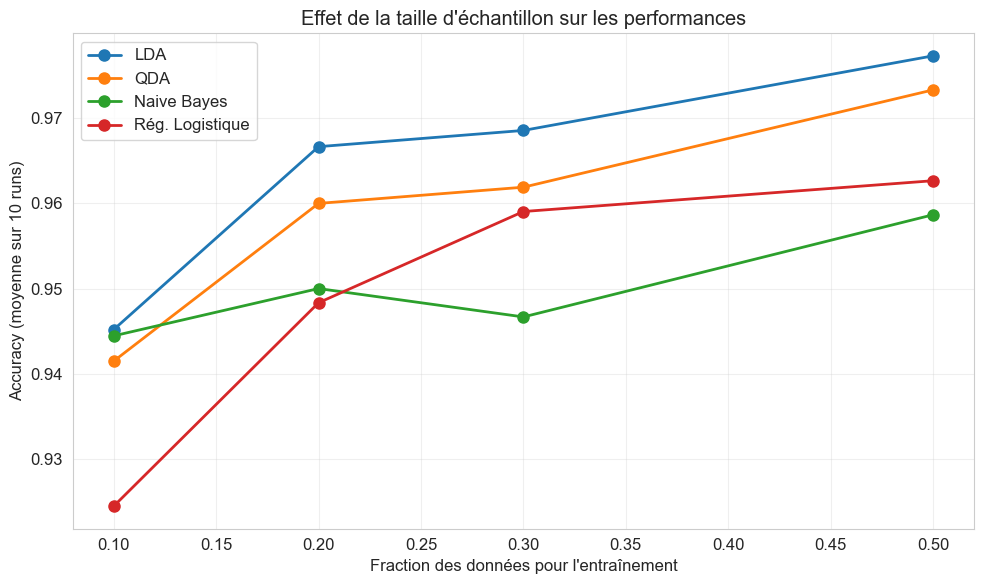

In [32]:
# Exercice 2 : Complétez ce code
train_sizes = [0.1, 0.2, 0.3, 0.5]
results = {name: [] for name in models_dict.keys()}

# Modèles avec régularisation pour QDA (évite les problèmes de covariance singulière)
models_ex2 = {
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.01),
    'Naive Bayes': GaussianNB(),
    'Rég. Logistique': LogisticRegression(max_iter=1000)
}

for train_size in train_sizes:
    # Plusieurs répétitions pour moyenner
    scores_per_model = {name: [] for name in models_ex2.keys()}
    
    for seed in range(10):
        X_tr, X_te, t_tr, t_te = train_test_split(
            X, t, train_size=train_size, random_state=seed, stratify=t
        )
        
        for name, model in models_ex2.items():
            model.fit(X_tr, t_tr)
            acc = accuracy_score(t_te, model.predict(X_te))
            scores_per_model[name].append(acc)
    
    for name in models_dict.keys():
        results[name].append(np.mean(scores_per_model[name]))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
for name, scores in results.items():
    ax.plot(train_sizes, scores, 'o-', label=name, linewidth=2, markersize=8)

ax.set_xlabel('Fraction des données pour l\'entraînement')
ax.set_ylabel('Accuracy (moyenne sur 10 runs)')
ax.set_title('Effet de la taille d\'échantillon sur les performances')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Question 5
Quel modèle semble le plus robuste avec peu de données ? Pourquoi ?

### Exercice 3 : Implémentation manuelle de LDA

Implémentez LDA "à la main" en calculant les moyennes et la covariance poolée.

In [33]:
# Exercice 3 : Implémentation manuelle de LDA
def lda_manual(X_train, t_train, X_test):
    """
    Implémentation manuelle de LDA.
    
    Retourne les prédictions pour X_test.
    """
    classes = np.unique(t_train)
    K = len(classes)
    N, D = X_train.shape
    
    # 1. Calculer les moyennes par classe μ_k
    means = np.zeros((K, D))
    for k in classes:
        means[k] = X_train[t_train == k].mean(axis=0)
    
    # 2. Calculer la covariance poolée Σ
    cov_pooled = np.zeros((D, D))
    for k in classes:
        X_k = X_train[t_train == k]
        cov_pooled += (X_k - means[k]).T @ (X_k - means[k])
    cov_pooled /= (N - K)
    
    # 3. Calculer les priors p(C_k)
    priors = np.array([np.mean(t_train == k) for k in classes])
    
    # 4. Calculer les fonctions discriminantes pour X_test
    cov_inv = np.linalg.inv(cov_pooled)
    
    # w_k = Σ^{-1} μ_k
    # w_k0 = -1/2 μ_k^T Σ^{-1} μ_k + ln p(C_k)
    scores = np.zeros((len(X_test), K))
    for k in classes:
        w_k = cov_inv @ means[k]
        w_k0 = -0.5 * means[k] @ cov_inv @ means[k] + np.log(priors[k])
        scores[:, k] = X_test @ w_k + w_k0
    
    # 5. Prédire la classe avec le score maximal
    predictions = np.argmax(scores, axis=1)
    
    return predictions

# Test
t_pred_manual = lda_manual(X_train, t_train, X_test)
acc_manual = accuracy_score(t_test, t_pred_manual)

print(f"Accuracy LDA manuel : {acc_manual:.4f}")
print(f"Accuracy LDA sklearn : {acc_lda:.4f}")
print(f"Prédictions identiques : {np.all(t_pred_manual == t_pred_lda)}")

Accuracy LDA manuel : 0.9111
Accuracy LDA sklearn : 0.9111
Prédictions identiques : True
